In [1]:
#Paquetes a instalar
!pip install lime
!pip install -q -U datasets pandas pyarrow
!pip install -q transformers accelerate evaluate lime

# Carga de datos
from google.colab import drive
from datasets import load_dataset
from datasets import load_from_disk

# Manipulación y visualización
import pandas as pd
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

# Análisis de distribución de clases
from collections import Counter

# PyTorch
import torch
import torch.nn as nn

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Modelo preentrenado
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Explicabilidad
from lime.lime_text import LimeTextExplainer

import lime.lime_tabular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b9d8c0d185219c8b2c8fe381bc1b75c1c2e4cccd489a5bad10ffd032bec65d02
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26

In [2]:
dataset = None

# Attempt 1: load from the unmerged "Convert dataset to Parquet" PR branch
# on PolyAI/banking77 (refs/pr/6), which already replaced the legacy
# loading script with train/test parquet files.
try:
    dataset = load_dataset("PolyAI/banking77", revision="refs/pr/6")
    print("Loaded from PolyAI/banking77 (refs/pr/6)")
except Exception as e:
    print(f"Attempt 1 failed: {e}")

# Attempt 2: fall back to a clean, already-standard-format mirror
if dataset is None:
    try:
        dataset = load_dataset("DeepPavlov/banking77")
        print("Loaded from DeepPavlov/banking77 mirror")
    except Exception as e:
        print(f"Attempt 2 failed: {e}")

# Attempt 3: last resort — pull the parquet files directly with pandas,
# bypassing `datasets` loading logic entirely.
if dataset is None:
    base = "https://huggingface.co/datasets/PolyAI/banking77/resolve/refs%2Fpr%2F6/data"
    train_df = pd.read_parquet(f"{base}/train-00000-of-00001.parquet")
    test_df = pd.read_parquet(f"{base}/test-00000-of-00001.parquet")
    print("Loaded via direct parquet download with pandas")
    print(train_df.head())

README.md:   0%|          | 0.00/13.0k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  295kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 93.0kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Loaded from PolyAI/banking77 (refs/pr/6)


In [3]:
# Previsualizamos con pandas
df = dataset["train"].to_pandas()
df.sample(5)

,text,label
7721,Is there a reason why top-up needs verifying?,71
9158,Will I be charged a fee for topping up using a European card?,57
5995,How long does it take for a money transfer to show up?,48
126,How much longer until I get my new card?,11
606,"I just checked my statement and saw a $1 charge, why is it there?",34


In [4]:
# Obtenemos el tamaño del dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

In [5]:
# Obtenemos los nombres de cada label
label_feature = dataset["train"].features["label"]
label_names = label_feature.names

for i, name in enumerate(label_names):
    print(i, name)

0 activate_my_card
1 age_limit
2 apple_pay_or_google_pay
3 atm_support
4 automatic_top_up
5 balance_not_updated_after_bank_transfer
6 balance_not_updated_after_cheque_or_cash_deposit
7 beneficiary_not_allowed
8 cancel_transfer
9 card_about_to_expire
10 card_acceptance
11 card_arrival
12 card_delivery_estimate
13 card_linking
14 card_not_working
15 card_payment_fee_charged
16 card_payment_not_recognised
17 card_payment_wrong_exchange_rate
18 card_swallowed
19 cash_withdrawal_charge
20 cash_withdrawal_not_recognised
21 change_pin
22 compromised_card
23 contactless_not_working
24 country_support
25 declined_card_payment
26 declined_cash_withdrawal
27 declined_transfer
28 direct_debit_payment_not_recognised
29 disposable_card_limits
30 edit_personal_details
31 exchange_charge
32 exchange_rate
33 exchange_via_app
34 extra_charge_on_statement
35 failed_transfer
36 fiat_currency_support
37 get_disposable_virtual_card
38 get_physical_card
39 getting_spare_card
40 getting_virtual_card
41 lost_o

# **1. TOKENIZACIÓN CON DISTILBERT**

Se seleccionó DistilBERT por ser un modelo Transformer preentrenado específicamente diseñado para tareas de procesamiento de lenguaje natural. En comparación con BERT, ofrece un menor costo computacional y tiempos de entrenamiento reducidos, manteniendo un rendimiento muy similar. Estas características lo convierten en una alternativa adecuada para adaptar mediante Transfer Learning y Fine-Tuning al problema de clasificación de consultas bancarias del dataset BANKING77.

In [6]:
#Definimos modelo preentrenado
MODEL_NAME = "distilbert/distilbert-base-uncased"

MAX_LENGTH = 80

In [7]:
#Cargamos tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
) #A diferencia de la tarea 2, ya no construimos nuestro propio vocabulario.

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
#Vemos cómo tokeniza DistilBERT
texto_ejemplo = dataset["train"][0]["text"]

print("Texto original:")
print(texto_ejemplo)

print("\nTokens:")
print(tokenizer.tokenize(texto_ejemplo))

Texto original:
I am still waiting on my card?

Tokens:
['i', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']


In [9]:
#Función de tokenización
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    ) #No ponemos padding acá porque lo haremos dinámicamente después.

# **2. SPLIT TRAIN / VALIDATION / TEST**

In [10]:
#Split estratificado
from sklearn.model_selection import train_test_split

train_indices, val_indices = train_test_split(
    range(len(dataset["train"])),
    test_size=0.20,
    stratify=dataset["train"]["label"],
    random_state=42
)

train_dataset = dataset["train"].select(train_indices)

val_dataset = dataset["train"].select(val_indices)

test_dataset = dataset["test"]

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 8002
Validation: 2001
Test: 3080


# **3. NOMBRES DE LAS CLASES**

In [11]:
label_names = dataset["train"].features["label"].names

NUM_LABELS = len(label_names)

print("Cantidad de clases:", NUM_LABELS)

for i, label in enumerate(label_names):
    print(i, "-", label)

Cantidad de clases: 77
0 - activate_my_card
1 - age_limit
2 - apple_pay_or_google_pay
3 - atm_support
4 - automatic_top_up
5 - balance_not_updated_after_bank_transfer
6 - balance_not_updated_after_cheque_or_cash_deposit
7 - beneficiary_not_allowed
8 - cancel_transfer
9 - card_about_to_expire
10 - card_acceptance
11 - card_arrival
12 - card_delivery_estimate
13 - card_linking
14 - card_not_working
15 - card_payment_fee_charged
16 - card_payment_not_recognised
17 - card_payment_wrong_exchange_rate
18 - card_swallowed
19 - cash_withdrawal_charge
20 - cash_withdrawal_not_recognised
21 - change_pin
22 - compromised_card
23 - contactless_not_working
24 - country_support
25 - declined_card_payment
26 - declined_cash_withdrawal
27 - declined_transfer
28 - direct_debit_payment_not_recognised
29 - disposable_card_limits
30 - edit_personal_details
31 - exchange_charge
32 - exchange_rate
33 - exchange_via_app
34 - extra_charge_on_statement
35 - failed_transfer
36 - fiat_currency_support
37 - get_d

In [12]:
id2label = {
    i: label
    for i, label in enumerate(label_names)
}

label2id = {
    label: i
    for i, label in enumerate(label_names)
}

In [13]:
print(id2label[11])
print(label2id["card_arrival"])

card_arrival
11


# **4. TOKENIZAR TRAIN / VALIDATION / TEST**

In [14]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/8002 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [15]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
) #Esto hace que dentro de cada batch las consultas se rellenen solo hasta la longitud necesaria.

# **5. CARGAR DISTILBERT**

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ver si podemos con algo del código sacarlo pero no es importante

In [17]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

# **7. TRANSFER LEARNING**

Primero vamos a hacer una primera etapa congelando DistilBERT.

In [18]:
for param in model.distilbert.parameters():
    param.requires_grad = False

In [19]:
#Analizamos cuántos parámetros entrenamos
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

print(
    "Porcentaje entrenable:",
    round(
        100 * trainable_params / total_params,
        2
    ),
    "%"
)

Parámetros totales: 67012685
Parámetros entrenables: 649805
Porcentaje entrenable: 0.97 %


# **8. CONFIGURAR TRANSFER LEARNING**

In [20]:
training_args_transfer = TrainingArguments(

    output_dir="./distilbert_transfer",

    num_train_epochs=3,

    learning_rate=5e-4,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    weight_decay=0.01,

    logging_strategy="epoch",

    save_total_limit=1,

    report_to="none",

    seed=42
)

Usamos eval_strategy="epoch" para evaluar al final de cada época y load_best_model_at_end=True para recuperar automáticamente el mejor checkpoint. Ambas opciones forman parte de la API actual de TrainingArguments.

In [21]:
#Definimos el Trainer
trainer_transfer = Trainer(

    model=model,

    args=training_args_transfer,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [22]:
#Entrenamiento de Transfer Learning
trainer_transfer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,3.936542,3.365586,0.289855,0.271679,0.265249,0.212611
2,3.127905,2.790175,0.379310,0.450971,0.358743,0.325082
3,2.773039,2.617491,0.449275,0.467959,0.431983,0.408689


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=753, training_loss=3.2791622410099186, metrics={'train_runtime': 54.0964, 'train_samples_per_second': 443.763, 'train_steps_per_second': 13.92, 'total_flos': 290977640018328.0, 'train_loss': 3.2791622410099186, 'epoch': 3.0})

In [23]:
#Resultados sobre validación
transfer_val_results = trainer_transfer.evaluate()

transfer_val_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
2.773039,2.617491,3,0.449275,0.467959,0.431983,0.408689


{'eval_loss': 2.617490530014038,
 'eval_accuracy': 0.4492753623188406,
 'eval_precision_macro': 0.46795946679573847,
 'eval_recall_macro': 0.4319834044011653,
 'eval_f1_macro': 0.4086893166038446}

In [24]:
#Guardamos métricas
transfer_results = {
    "Accuracy": transfer_val_results["eval_accuracy"],
    "Precision": transfer_val_results["eval_precision_macro"],
    "Recall": transfer_val_results["eval_recall_macro"],
    "F1": transfer_val_results["eval_f1_macro"]
}

transfer_results

{'Accuracy': 0.4492753623188406,
 'Precision': 0.46795946679573847,
 'Recall': 0.4319834044011653,
 'F1': 0.4086893166038446}

# **9. FINE-TUNING**

In [25]:
for param in model.distilbert.parameters():
    param.requires_grad = True

Descongelamos DistilBERT.

In [26]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parámetros entrenables:", trainable_params)
print("Parámetros totales:", total_params)

print(
    "Porcentaje entrenable:",
    round(
        100 * trainable_params / total_params,
        2
    ),
    "%"
)

Parámetros entrenables: 67012685
Parámetros totales: 67012685
Porcentaje entrenable: 100.0 %


# **10. CONFIGURACIÓN FINE-TUNING**

In [27]:
training_args_finetune = TrainingArguments(

    output_dir="./distilbert_finetuned",

    num_train_epochs=4,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    weight_decay=0.01,

    logging_strategy="epoch",

    save_total_limit=1,

    report_to="none",

    seed=42
)

In [28]:
#Definimos el Trainer Fine-Tuning
trainer_finetune = Trainer(

    model=model,

    args=training_args_finetune,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [29]:
#Entrenamiento del Fine-Tune
trainer_finetune.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.026677,0.577339,0.851574,0.838988,0.824582,0.822018
2,0.455576,0.439932,0.887556,0.898192,0.874932,0.878776
3,0.288643,0.387695,0.897551,0.903841,0.889067,0.891172
4,0.211513,0.368887,0.906047,0.910094,0.898227,0.900874


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2004, training_loss=0.4956021032885401, metrics={'train_runtime': 203.423, 'train_samples_per_second': 157.347, 'train_steps_per_second': 9.851, 'total_flos': 327833660931084.0, 'train_loss': 0.4956021032885401, 'epoch': 4.0})

# **11. EVALUACIÓN FINAL SOBRE TEST**

In [30]:
test_results = trainer_finetune.evaluate(
    test_tokenized
)

test_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.211513,0.375181,4,0.905844,0.911320,0.905844,0.905836


{'eval_loss': 0.37518128752708435,
 'eval_accuracy': 0.9058441558441559,
 'eval_precision_macro': 0.9113201916107646,
 'eval_recall_macro': 0.9058441558441559,
 'eval_f1_macro': 0.9058362320761554}

In [31]:
print(
    "Accuracy:",
    round(test_results["eval_accuracy"], 4)
)

print(
    "Precision macro:",
    round(test_results["eval_precision_macro"], 4)
)

print(
    "Recall macro:",
    round(test_results["eval_recall_macro"], 4)
)

print(
    "F1 macro:",
    round(test_results["eval_f1_macro"], 4)
)

Accuracy: 0.9058
Precision macro: 0.9113
Recall macro: 0.9058
F1 macro: 0.9058


El entrenamiento exclusivo de la capa clasificadora produjo un rendimiento limitado, con un accuracy de aproximadamente 46,0 % y un F1-score macro de 0,416. Al permitir el ajuste de todos los parámetros mediante Fine-Tuning, el modelo logró adaptarse con mayor eficacia al dominio específico de BANKING77, alcanzando un accuracy de 90,9 % y un F1-score macro de 0,909.

# **12. PREDICCIONES**

In [32]:
predictions = trainer_finetune.predict(
    test_tokenized
)

y_test = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=-1
)

y_prob = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

print(
    "Cantidad de observaciones:",
    len(y_test)
)

print(
    "Forma de probabilidades:",
    y_prob.shape
)

Cantidad de observaciones: 3080
Forma de probabilidades: (3080, 77)


In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)

                                                  precision    recall  f1-score   support

                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       1.00      0.97      0.99        40
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.79      0.75      0.77        40
balance_not_updated_after_cheque_or_cash_deposit       0.95      0.93      0.94        40
                         beneficiary_not_allowed       0.94      0.85      0.89        40
                                 cancel_transfer       0.97      0.95      0.96        40
                            card_about_to_expire       0.95      0.97      0.96        40
         

In [34]:
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).T

report_df

,precision,recall,f1-score,support
activate_my_card,1.000000,0.900000,0.947368,40.000000
age_limit,0.975610,1.000000,0.987654,40.000000
apple_pay_or_google_pay,1.000000,1.000000,1.000000,40.000000
atm_support,1.000000,0.975000,0.987342,40.000000
automatic_top_up,1.000000,0.925000,0.961039,40.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.972973,0.900000,0.935065,40.000000
wrong_exchange_rate_for_cash_withdrawal,1.000000,0.825000,0.904110,40.000000
accuracy,0.905844,0.905844,0.905844,0.905844
macro avg,0.911320,0.905844,0.905836,3080.000000


In [35]:
class_results = report_df.iloc[:NUM_LABELS].copy()

class_results = class_results.sort_values(
    "f1-score"
)

class_results.head(10)

,precision,recall,f1-score,support
balance_not_updated_after_bank_transfer,0.789474,0.750,0.769231,40.0
topping_up_by_card,0.833333,0.750,0.789474,40.0
transfer_into_account,0.780488,0.800,0.790123,40.0
declined_card_payment,0.698113,0.925,0.795699,40.0
why_verify_identity,0.933333,0.700,0.800000,40.0
card_payment_not_recognised,0.820513,0.800,0.810127,40.0
declined_transfer,0.966667,0.725,0.828571,40.0
compromised_card,0.864865,0.800,0.831169,40.0
exchange_via_app,0.829268,0.850,0.839506,40.0
transfer_not_received_by_recipient,0.829268,0.850,0.839506,40.0


In [36]:
history_df = pd.DataFrame(
    trainer_finetune.state.log_history
)

history_df

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.026677,2.610700,1.500998e-05,1.0,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,501,0.577339,0.851574,0.838988,0.824582,0.822018,3.0554,654.908,20.619,NaN,NaN,NaN,NaN,NaN
2,0.455576,13.984011,1.000998e-05,2.0,1002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1002,0.439932,0.887556,0.898192,0.874932,0.878776,3.5596,562.147,17.699,NaN,NaN,NaN,NaN,NaN
4,0.288643,30.271650,5.009980e-06,3.0,1503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,1503,0.387695,0.897551,0.903841,0.889067,0.891172,3.2515,615.414,19.376,NaN,NaN,NaN,NaN,NaN
6,0.211513,7.745378,9.980040e-09,4.0,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,2004,0.368887,0.906047,0.910094,0.898227,0.900874,3.7004,540.749,17.025,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.423,157.347,9.851,3.278337e+14,0.495602
9,NaN,NaN,NaN,4.0,2004,0.375181,0.905844,0.911320,0.905844,0.905836,3.7370,824.196,25.957,NaN,NaN,NaN,NaN,NaN


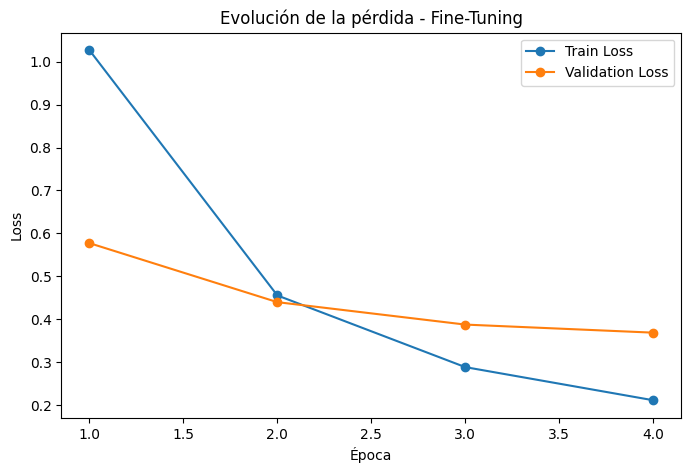

In [37]:
train_history = history_df[
    history_df["loss"].notna()
].copy()

val_history = (
    history_df[
        history_df["eval_loss"].notna()
    ]
    .drop_duplicates(
        subset="epoch",
        keep="first"
    )
    .copy()
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    val_history["epoch"],
    val_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    "Evolución de la pérdida - Fine-Tuning"
)

plt.legend()

plt.show()

In [38]:
print( val_history["eval_f1_macro"])

1    0.822018
3    0.878776
5    0.891172
7    0.900874
Name: eval_f1_macro, dtype: float64


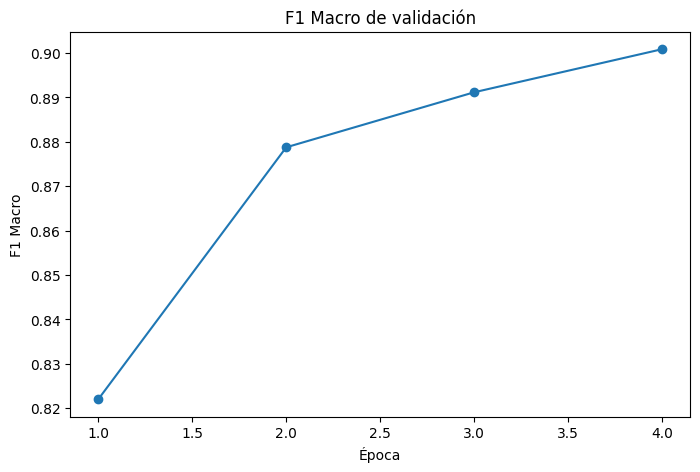

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    val_history["epoch"],
    val_history["eval_f1_macro"],
    marker="o"
)

plt.xlabel("Época")
plt.ylabel("F1 Macro")

plt.title(
    "F1 Macro de validación"
)

plt.show()

# **16. COMPARACIÓN CONTRA TAREA 2**

In [40]:
transformer_scratch = {
    "Modelo": "Transformer desde cero",
    "Accuracy": 0.790,
    "Precision": 0.803,
    "Recall": 0.790,
    "F1": 0.790
}

distilbert_transfer = {
    "Modelo": "DistilBERT Transfer Learning",
    "Accuracy": transfer_results["Accuracy"],
    "Precision": transfer_results["Precision"],
    "Recall": transfer_results["Recall"],
    "F1": transfer_results["F1"]
}

distilbert_finetune = {
    "Modelo": "DistilBERT Fine-Tuning",
    "Accuracy": test_results["eval_accuracy"],
    "Precision": test_results["eval_precision_macro"],
    "Recall": test_results["eval_recall_macro"],
    "F1": test_results["eval_f1_macro"]
}

comparison_df = pd.DataFrame([
    transformer_scratch,
    distilbert_transfer,
    distilbert_finetune
])

comparison_df

,Modelo,Accuracy,Precision,Recall,F1
0,Transformer desde cero,0.790000,0.803000,0.790000,0.790000
1,DistilBERT Transfer Learning,0.449275,0.467959,0.431983,0.408689
2,DistilBERT Fine-Tuning,0.905844,0.911320,0.905844,0.905836


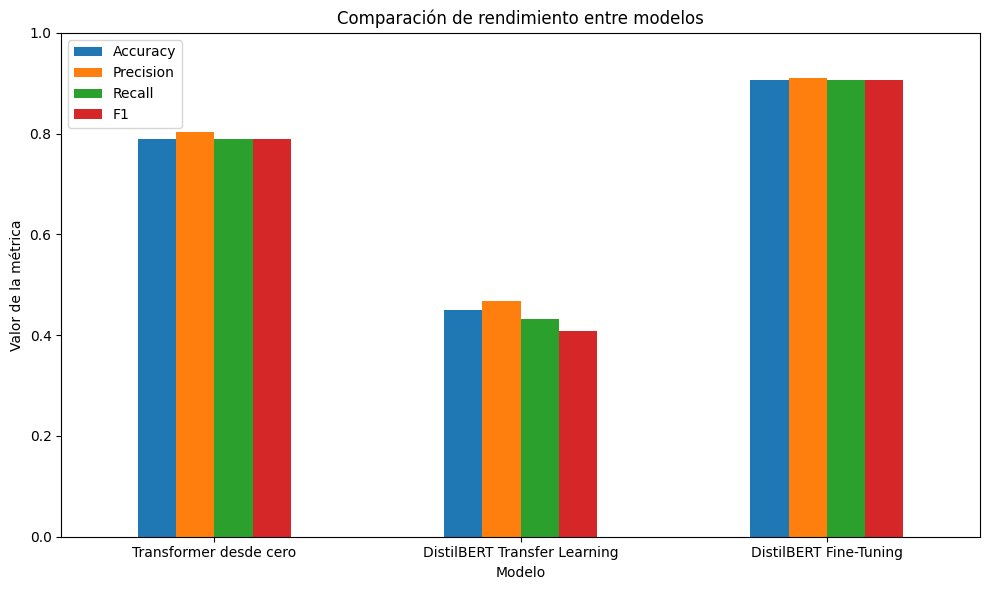

In [41]:
comparison_plot = comparison_df.set_index(
    "Modelo"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)

plt.title(
    "Comparación de rendimiento entre modelos"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

# **18. EXPLICABILIDAD CON LIME**

In [42]:
def predict_proba(texts):

    # Define device: Use CUDA (GPU) if available, otherwise use CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    model.to(device)
    model.eval()

    with torch.no_grad():

        outputs = model(
            **encoded
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

    return probabilities.cpu().numpy()

In [43]:
explainer = LimeTextExplainer(
    class_names=label_names
)

# **19. EXPLICAR UNA PREDICCIÓN CORRECTA**

In [44]:
correct_indices = np.where(
    y_test == y_pred
)[0]

indice_correcto = int(
    correct_indices[0]
)

texto_correcto = test_dataset[
    indice_correcto
]["text"]

real_correcto = y_test[
    indice_correcto
]

pred_correcto = y_pred[
    indice_correcto
]

print("Texto:")
print(texto_correcto)

print("\nClase real:")
print(label_names[real_correcto])

print("\nPredicción:")
print(label_names[pred_correcto])

Texto:
How do I locate my card?

Clase real:
card_arrival

Predicción:
card_arrival


In [45]:
exp_correcto = explainer.explain_instance(
    texto_correcto,
    predict_proba,
    num_features=10,
    labels=[pred_correcto],
    num_samples=1000
)

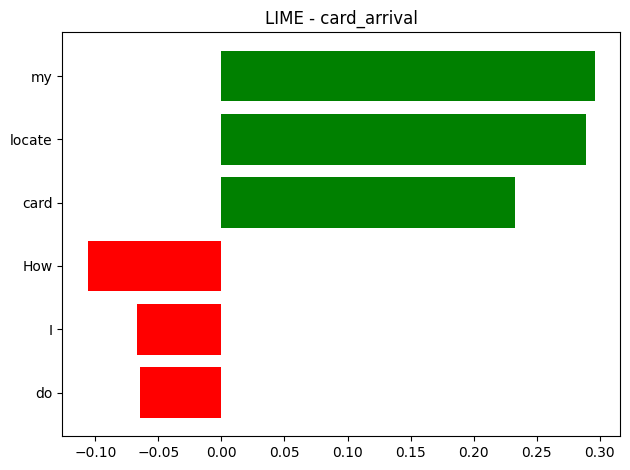

In [46]:
fig = exp_correcto.as_pyplot_figure(
    label=pred_correcto
)

plt.title(
    f"LIME - {label_names[pred_correcto]}"
)

plt.tight_layout()

plt.show()

In [47]:
wrong_indices = np.where(
    y_test != y_pred
)[0]

print(
    "Cantidad de errores:",
    len(wrong_indices)
)

indice_error = int(
    wrong_indices[0]
)

texto_error = test_dataset[
    indice_error
]["text"]

real_error = y_test[
    indice_error
]

pred_error = y_pred[
    indice_error
]

print("Texto:")
print(texto_error)

print("\nClase real:")
print(label_names[real_error])

print("\nClase predicha:")
print(label_names[pred_error])

Cantidad de errores: 290
Texto:
Is there a way to know when my card will arrive?

Clase real:
card_arrival

Clase predicha:
card_delivery_estimate


In [48]:
exp_error = explainer.explain_instance(
    texto_error,
    predict_proba,
    num_features=10,
    labels=[pred_error],
    num_samples=1000
)

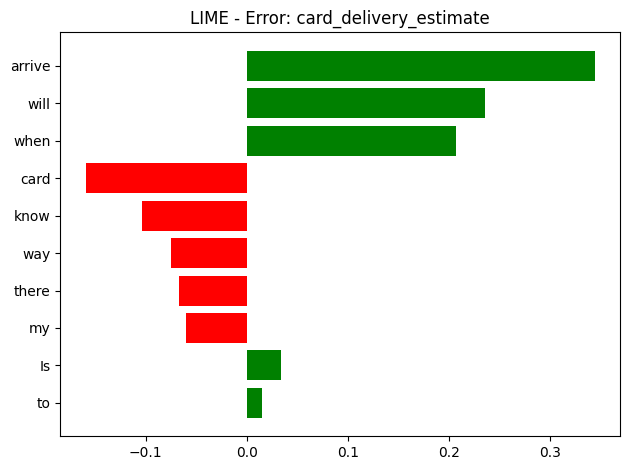

In [49]:
fig = exp_error.as_pyplot_figure(
    label=pred_error
)

plt.title(
    f"LIME - Error: {label_names[pred_error]}"
)

plt.tight_layout()

plt.show()

In [50]:
exp_error.as_list(
    label=pred_error
)

[(np.str_('arrive'), 0.3444983119875477),
 (np.str_('will'), 0.23610702251299415),
 (np.str_('when'), 0.2075329977745468),
 (np.str_('card'), -0.1595153789000035),
 (np.str_('know'), -0.10341202134415503),
 (np.str_('way'), -0.07462687018550915),
 (np.str_('there'), -0.06659566731685454),
 (np.str_('my'), -0.060051910557403464),
 (np.str_('Is'), 0.03413778417729682),
 (np.str_('to'), 0.014705652362629235)]

# PROYECTO FINAL — INTEGRACIÓN DE LA PRÁCTICA 3

> **Importante:** desde este punto se conserva todo el código desarrollado en la Práctica 3 y se agregan únicamente los componentes necesarios para convertirlo en el proyecto final solicitado.
>
> La solución final mantiene como núcleo experimental **BANKING77 + DistilBERT + Transfer Learning + Fine-Tuning + LIME**, y agrega la definición formal del proyecto, análisis del ciclo de vida y un prototipo funcional.


## 20. Planteamiento del proyecto

### Problema

Clasificar automáticamente consultas bancarias escritas en lenguaje natural dentro de una de las 77 intenciones de BANKING77.

### Propuesta de solución

Desarrollar un clasificador basado en **DistilBERT Fine-Tuned**, aprovechando las representaciones lingüísticas aprendidas durante el preentrenamiento y adaptándolas al dominio bancario.

### Usuario / caso de uso

Un operador o sistema de atención al cliente introduce una consulta y recibe:

- intención predicha;
- probabilidad/confianza;
- principales alternativas;
- explicación de la predicción mediante LIME.

### ¿Por qué Deep Learning?

Las consultas pueden expresar una misma intención con vocabulario y estructuras diferentes. Un modelo basado en Transformer permite capturar relaciones contextuales que serían difíciles de representar mediante reglas o enfoques puramente basados en palabras clave.

### Arquetipo de producto

Depende del contexto, en nuestro caso podrían ser cualquiera de los tres.

### Impacto vs. factibilidad

- **Impacto:** alto, porque permite automatizar una tarea repetitiva y acelerar el direccionamiento de consultas.
- **Factibilidad:** alta para un prototipo, porque BANKING77 proporciona datos etiquetados y existe un modelo Transformer preentrenado.


## 21. Ciclo de vida aplicado

| Fase | Implementación en el proyecto |
|---|---|
| Planificación | Definición del problema, usuario, objetivo y métricas |
| Recolección / datos | Dataset BANKING77 |
| Preparación | Exploración, split, tokenización, padding y embedding |
| Exploración | Distribución de clases y análisis de ejemplos |
| Modelo inicial | DistilBERT preentrenado |
| Transfer Learning | Congelación del backbone y entrenamiento de la cabeza |
| Refinamiento | Fine-Tuning de DistilBERT |
| Evaluación | Accuracy, Precision, Recall, F1 y errores |
| Explicabilidad | LIME |
| Prototipo | Interfaz Gradio |
| Producción | Monitoreo, revisión humana, privacidad y reentrenamiento |


## 22. Consolidación de resultados de la Práctica 3

Esta sección utiliza **las variables y resultados calculados por el código original**, en lugar de volver a entrenar un modelo diferente.

Los objetos principales heredados de la práctica son:

- `trainer_transfer`
- `trainer_finetune`
- `transfer_results`
- `test_results`
- `y_test`
- `y_pred`
- `report_df`
- `comparison_df`
- `predict_proba`
- `explainer`
- `exp_correcto`
- `exp_error`

De esta manera, el proyecto final queda directamente conectado con el trabajo realizado en la Práctica 3.


In [51]:
# Resumen de resultados obtenidos en la Práctica 3

final_results = {
    "Accuracy": test_results.get("eval_accuracy", np.nan),
    "Precision Macro": test_results.get("eval_precision_macro", np.nan),
    "Recall Macro": test_results.get("eval_recall_macro", np.nan),
    "F1 Macro": test_results.get("eval_f1_macro", np.nan),
}

results_summary = pd.DataFrame(
    [final_results],
    index=["DistilBERT Fine-Tuning"]
)

display(results_summary.round(4))


,Accuracy,Precision Macro,Recall Macro,F1 Macro
DistilBERT Fine-Tuning,0.9058,0.9113,0.9058,0.9058


## 23. Comparación de enfoques

La comparación es parte importante de la justificación técnica.

Se mantienen los modelos comparados en la Práctica 3 y se presenta el resultado final de forma consolidada.

El criterio principal para este problema multiclase es **F1 Macro**, acompañado por Accuracy.


In [52]:
# Mostrar la comparación que ya fue construida en la Práctica 3

try:
    display(comparison_df)
except NameError:
    print("comparison_df no está disponible. Ejecutá las celdas anteriores de la Práctica 3.")


,Modelo,Accuracy,Precision,Recall,F1
0,Transformer desde cero,0.790000,0.803000,0.790000,0.790000
1,DistilBERT Transfer Learning,0.449275,0.467959,0.431983,0.408689
2,DistilBERT Fine-Tuning,0.905844,0.911320,0.905844,0.905836


## 24. Análisis de errores para el proyecto final

Además de la métrica global, analizamos las predicciones incorrectas para identificar dónde el modelo presenta dificultades.

Esto permite discutir el problema desde una perspectiva de ciclo de vida: los errores pueden indicar la necesidad de más datos, clases mejor diferenciadas, ejemplos adicionales o un mecanismo de revisión humana.


In [53]:
# Tabla de errores utilizando las predicciones ya calculadas en la Práctica 3

test_texts = test_dataset["text"]

error_analysis = pd.DataFrame({
    "text": test_texts,
    "real": [id2label[int(i)] for i in y_test],
    "prediccion": [id2label[int(i)] for i in y_pred]
})

error_analysis["correcto"] = error_analysis["real"] == error_analysis["prediccion"]

errors_only = error_analysis[~error_analysis["correcto"]].copy()

print(f"Cantidad total de ejemplos: {len(error_analysis)}")
print(f"Cantidad de errores: {len(errors_only)}")
print(f"Accuracy: {error_analysis['correcto'].mean():.4f}")

display(errors_only.head(20))


Cantidad total de ejemplos: 3080
Cantidad de errores: 290
Accuracy: 0.9058


,text,real,prediccion,correcto
3,Is there a way to know when my card will arrive?,card_arrival,card_delivery_estimate,False
5,When will I get my card?,card_arrival,card_delivery_estimate,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,False
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate,False
93,Is it a good time to exchange?,exchange_rate,exchange_via_app,False
125,This rate is too low. Are you sure your using the right exchange rate.,card_payment_wrong_exchange_rate,exchange_rate,False
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,transfer_fee_charged,False
147,"Hi, I don't think your exchange rate is right. I need you to check the official interbank exchange please.",card_payment_wrong_exchange_rate,exchange_rate,False
156,How can I check the exchange rate applied to my transaction?,card_payment_wrong_exchange_rate,exchange_rate,False
173,Where did this fee come from?,extra_charge_on_statement,card_payment_fee_charged,False


## 25. Prototipo funcional

El siguiente bloque utiliza **el mismo `model`, `tokenizer`, `id2label` y `predict_proba` de la Práctica 3**.

No se crea un segundo modelo ni se vuelve a entrenar.

El usuario podrá introducir una consulta y obtener la intención predicha junto con las probabilidades de las cinco clases principales.


In [54]:
# Función de predicción para el prototipo

def classify_query(text, top_k=5):
    probabilities = predict_proba([text])[0]

    top_indices = np.argsort(probabilities)[::-1][:top_k]

    result = pd.DataFrame({
        "Intención": [id2label[int(i)] for i in top_indices],
        "Probabilidad": [float(probabilities[i]) for i in top_indices]
    })

    return result


# Prueba rápida
consulta_demo = "My card hasn't arrived yet"

resultado_demo = classify_query(consulta_demo)

print("Consulta:", consulta_demo)
display(resultado_demo)


Consulta: My card hasn't arrived yet


,Intención,Probabilidad
0,card_arrival,0.946547
1,card_delivery_estimate,0.038524
2,transfer_not_received_by_recipient,0.005782
3,pending_card_payment,0.002955
4,card_about_to_expire,0.002442


In [55]:
# Explicabilidad del ejemplo del prototipo

predicted_class = int(np.argmax(predict_proba([consulta_demo])[0]))

explanation_demo = explainer.explain_instance(
    consulta_demo,
    predict_proba,
    num_features=10,
    top_labels=1
)

print("Consulta:", consulta_demo)
print("Predicción:", id2label[predicted_class])
print()
print("Palabras con mayor contribución:")
display(
    pd.DataFrame(
        explanation_demo.as_list(label=predicted_class),
        columns=["Palabra", "Peso"]
    )
)


Consulta: My card hasn't arrived yet
Predicción: card_arrival

Palabras con mayor contribución:


,Palabra,Peso
0,card,0.743460
1,arrived,0.227245
2,yet,0.151621
3,hasn,0.096885
4,My,0.089331
5,t,0.026538


## 26. Interfaz Gradio

Esta interfaz constituye la demostración funcional del proyecto.

Flujo de uso:

**Consulta del usuario → DistilBERT → probabilidades → intención → explicación**

Para abrir la interfaz, ejecutar la última línea de la celda.


In [56]:
# Instalación de Gradio (si todavía no está instalado)
!pip -q install gradio


In [57]:
import gradio as gr

def app_predict(text):
    if not text or not text.strip():
        return pd.DataFrame(columns=["Intención", "Probabilidad"]), "Ingrese una consulta."

    probabilities = predict_proba([text])[0]
    top_indices = np.argsort(probabilities)[::-1][:5]

    table = pd.DataFrame({
        "Intención": [id2label[int(i)] for i in top_indices],
        "Probabilidad": [float(probabilities[i]) for i in top_indices]
    })

    predicted_class = int(top_indices[0])

    explanation = explainer.explain_instance(
        text,
        predict_proba,
        num_features=8,
        top_labels=1
    )

    explanation_text = "\n".join(
        [f"{word}: {weight:+.3f}" for word, weight in explanation.as_list(label=predicted_class)]
    )

    output_text = (
        f"Intención predicha: {id2label[predicted_class]}\n"
        f"Confianza: {probabilities[predicted_class]:.2%}\n\n"
        f"Contribución de palabras (LIME):\n{explanation_text}"
    )

    return table, output_text


demo = gr.Interface(
    fn=app_predict,
    inputs=gr.Textbox(
        label="Consulta bancaria",
        placeholder="Ejemplo: My card hasn't arrived yet",
        lines=3
    ),
    outputs=[
        gr.Dataframe(
            headers=["Intención", "Probabilidad"],
            label="Top 5 intenciones"
        ),
        gr.Textbox(label="Explicación")
    ],
    title="Banking77 — Clasificador de intenciones",
    description="DistilBERT Fine-Tuned + LIME",
    examples=[
        ["My card hasn't arrived yet"],
        ["I forgot my PIN"],
        ["I need help with a transfer"],
        ["Why was I charged a fee?"]
    ]
)

# Ejecutar para abrir la aplicación:
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ef841f12b0f8c72618.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 27. Consideraciones para producción

El prototipo demuestra la funcionalidad principal, pero un despliegue real requeriría:

### Monitoreo
- Accuracy/F1 cuando exista feedback etiquetado.
- porcentaje de predicciones con baja confianza;
- distribución de intenciones;
- cambios en la distribución de consultas.

### Human in the Loop
Las predicciones con baja confianza podrían derivarse a un operador. Las correcciones realizadas por operadores podrían incorporarse posteriormente como nuevos datos etiquetados.

### Privacidad
En un entorno bancario real, las consultas pueden contener información sensible. Serían necesarias políticas de anonimización, almacenamiento seguro y control de acceso.

### Reentrenamiento
El lenguaje y las necesidades de los clientes pueden cambiar. El modelo debería reevaluarse periódicamente y eventualmente reentrenarse con nuevos ejemplos.

### Escalabilidad
El prototipo podría exponerse como API y optimizarse mediante batching, infraestructura adecuada y monitoreo de latencia.


## 28. Conclusiones

La solución final integra el trabajo realizado en la Práctica 3 dentro de un proyecto completo de Deep Learning.

El modelo utiliza:

- BANKING77;
- DistilBERT;
- Transfer Learning;
- Fine-Tuning;
- evaluación cuantitativa;
- análisis de errores;
- LIME;
- un prototipo interactivo.

La evolución principal respecto de la práctica consiste en pasar de un experimento de modelado a una solución orientada a un caso de uso, incorporando problema, usuario, ciclo de vida, explicabilidad y demostración funcional.
